## Uczenie maszynowe – zastosowania
### Zajęcia laboratoryjne
# 3. Regresja liniowa – zadanie

## Zadanie 3

### Część podstawowa (4 punkty)

Plik `fires_thefts.csv` zawiera rzeczywiste dane zebrane przez *U.S. Commission on Civil Rights*, przedstawiające liczbę pożarów w danej dzielnicy na tysiąc gospodarstw domowych (pierwsza kolumna) oraz liczbę włamań w tej samej dzielnicy na tysiąc mieszkańców (druga kolumna). 

Stwórz model (regresja liniowa) przewidujący liczbę włamań na podstawie liczby pożarów:
 * Oblicz parametry $\theta$ krzywej regresyjnej za pomocą metody gradientu prostego (*gradient descent*). Możesz wybrać wersję iteracyjną lub macierzową algorytmu.
 * Wykorzystując uzyskaną krzywą regresyjną przepowiedz liczbę włamań na tysiąc mieszkańców dla dzielnicy, w której występuje średnio 50, 100, 200 pożarów na tysiąc gospodarstw domowych.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Wczytanie danych

data = pd.read_csv("fires_thefts.csv", names=["fires", "thefts"])
# print(data[:10])

fires_data = data[["fires"]].to_numpy().flatten()
thefts_data = data[["thefts"]].to_numpy().flatten()

# print(fires[:10])
# print(thefts[:10])

In [ ]:
def h(theta, x):
    return theta[0] + theta[1] * x

def J(h, theta, x, y):
    """Funkcja kosztu"""
    m = len(y)
    return 1.0 / (2 * m) * sum((h(theta, x[i]) - y[i])**2 for i in range(m))

def gradient_descent(h, cost_fun, theta, x, y, alpha, eps):
    current_cost = cost_fun(h, theta, x, y)
    log = [[current_cost, theta]]  # log przechowuje wartości kosztu i parametrów
    m = len(y)
    while True:
        term0 = alpha/float(m) * sum(h(theta, x[i]) - y[i] for i in range(m))
        term1 = alpha/float(m) * sum((h(theta, x[i]) - y[i]) * x[i] for i in range(m))
        new_theta = [float(theta[0] - term0), float(theta[1] - term1)]
        theta = new_theta
        prev_cost = current_cost
        current_cost = cost_fun(h, theta, x, y)
        if current_cost > prev_cost:
            print("Zbyt duża długość kroku!")
            break
        if abs(prev_cost - current_cost) <= eps:
            break     
        log.append([current_cost, theta])
    return theta, log

In [47]:
best_theta, log = gradient_descent(h, J, [0.0, 0.0], fires_data, thefts_data, alpha=0.001, eps=0.0000001)

print(f"Theta 0: {best_theta[0]}, Theta 1: {best_theta[1]}")

example_fires = [50, 100, 200] # Przykładowe liczby pożarów

for fire in example_fires:
    predicted_thefts = h(best_theta, fire)
    print(f"Przy {fire} pożarach, przewidywana liczba kradzieży to: {predicted_thefts}")


Theta 0: 16.96747476186552, Theta 1: 1.3148504023266523
Przy 50 pożarach, przewidywana liczba kradzieży to: 82.70999487819813
Przy 100 pożarach, przewidywana liczba kradzieży to: 148.45251499453076
Przy 200 pożarach, przewidywana liczba kradzieży to: 279.93755522719596


### Część zaawansowana (2 punkty)

Dla różnych wartości długości kroku $\alpha \in \{ 0.001, 0.01 , 0.1 \}$ stwórz wykres, który zilustruje progresję wartości $J(\theta)$ dla pierwszych 200 króków algorytmu gradientu prostego:
 * Oś $x$ wykresu to kolejne kroki algorytmu – od 0 do 200.
 * Oś $y$ wykresu to wartosci $J(\theta)$.
 * Wykres powinien skłądać się z trzech krzywych:
   1. dla $\alpha = 0.001$
   2. dla $\alpha = 0.01$
   3. dla $\alpha = 0.1$

In [48]:
# gradient z limitem kroków
def gradient_descent2(h, cost_fun, theta, x, y, alpha, eps, steps):
    current_cost = cost_fun(h, theta, x, y)
    log = [[current_cost, theta]]
    m = len(y)

    for _ in range(steps):
        term0 = alpha/float(m) * sum(h(theta, x[i]) - y[i] for i in range(m))
        term1 = alpha/float(m) * sum((h(theta, x[i]) - y[i]) * x[i] for i in range(m))
        new_theta = [float(theta[0] - term0), float(theta[1] - term1)]
        theta = new_theta
        prev_cost = current_cost
        current_cost = cost_fun(h, theta, x, y)
        if current_cost > prev_cost:
            print("Zbyt duża długość kroku!")
            break
        if abs(prev_cost - current_cost) <= eps:
            break     
        log.append([current_cost, theta])
    return theta, log

Alpha: 0.001 | Theta 0: 6.0420 | Theta 1: 2.3341 | Koszt: 615.3586
Alpha: 0.01 | Theta 0: 26.7569 | Theta 1: 12.9312 | Koszt: 228.6290
Alpha: 0.1 | Theta 0: 23.3014 | Theta 1: 37.3122 | Koszt: 185.2151


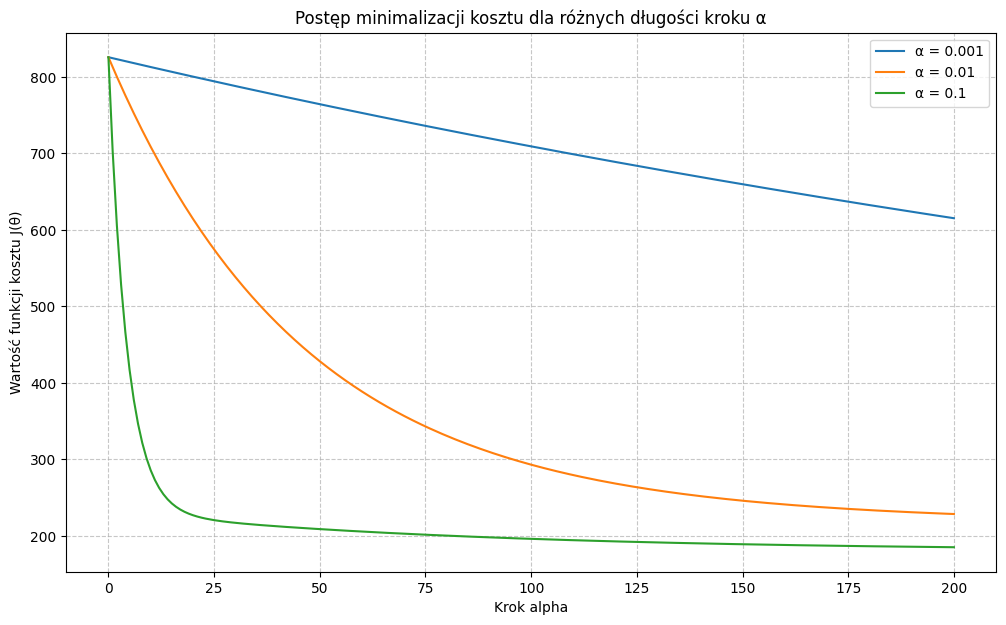

In [ ]:

alpha_size = [0.001, 0.01, 0.1]
step_value = 200

# Normalizacja danych - skalowanie do zakresu [0, 1]
fires_min = fires_data.min()
fires_max = fires_data.max()
fires_scaled = (fires_data - fires_min) / (fires_max - fires_min)

plt.figure(figsize=(12, 7))

for a in alpha_size:
    best_theta, log = gradient_descent2(h, J, [0.0, 0.0], fires_scaled, thefts_data, alpha=a, eps=0.0000001, steps=step_value)
    print(f"Alpha: {a} | Theta 0: {best_theta[0]:.4f} | Theta 1: {best_theta[1]:.4f} | Koszt: {log[-1][0]:.4f}")
    costs = [item[0] for item in log]
    plt.plot(range(len(costs)), costs, label=f'α = {a}')


# Config wykresu
plt.xlabel('Krok alpha')
plt.ylabel('Wartość funkcji kosztu J(θ)')
plt.title('Postęp minimalizacji kosztu dla różnych długości kroku α')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7) 

plt.show()
